In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

BLUE   = "#4C72B0"
ORANGE = "#DD8452"
GREEN  = "#55A868"
RED    = "#C44E52"
PURPLE = "#8172B2"

df = pd.read_csv("caffeine_sleep_dataset.csv")
print(df.shape)
print(df.head())

(50, 5)
       Country  Coffee_kg_per_capita  Sleep_Duration_hrs  Sleep_Quality  \
0      Finland                  12.0                7.88          0.791   
1       Norway                   9.9                7.81          0.783   
2      Iceland                   9.0                7.72          0.779   
3      Denmark                   8.7                7.67          0.772   
4  Netherlands                   8.3                7.55          0.765   

      Region  
0  N. Europe  
1  N. Europe  
2  N. Europe  
3  N. Europe  
4  W. Europe  


Question 1


Sleep Duration (hrs)
  Mean   = 7.366
  Median = 7.450
  SD     = 0.338
  Min    = 6.320
  Max    = 7.990
  IQR    = 0.460
  Skew   = -0.876

Sleep Quality Score
  Mean   = 0.744
  Median = 0.748
  SD     = 0.027
  Min    = 0.695
  Max    = 0.800
  IQR    = 0.040
  Skew   = 0.051


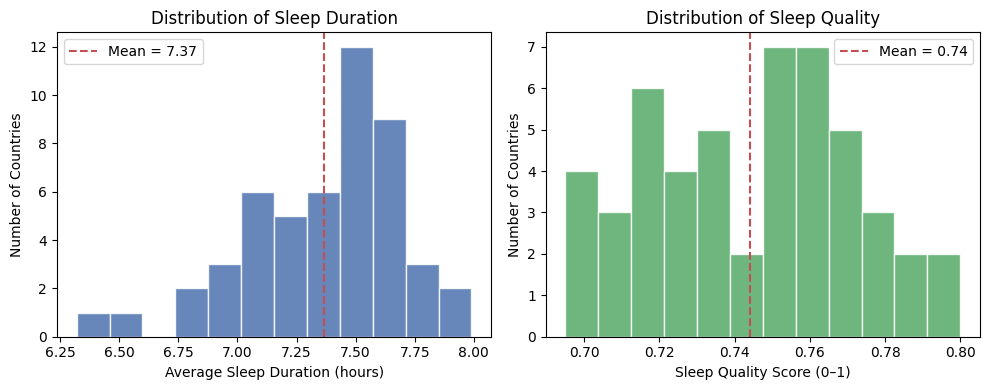

C:\Users\pavlo\AppData\Local\Temp\ipykernel_10428\2922497578.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


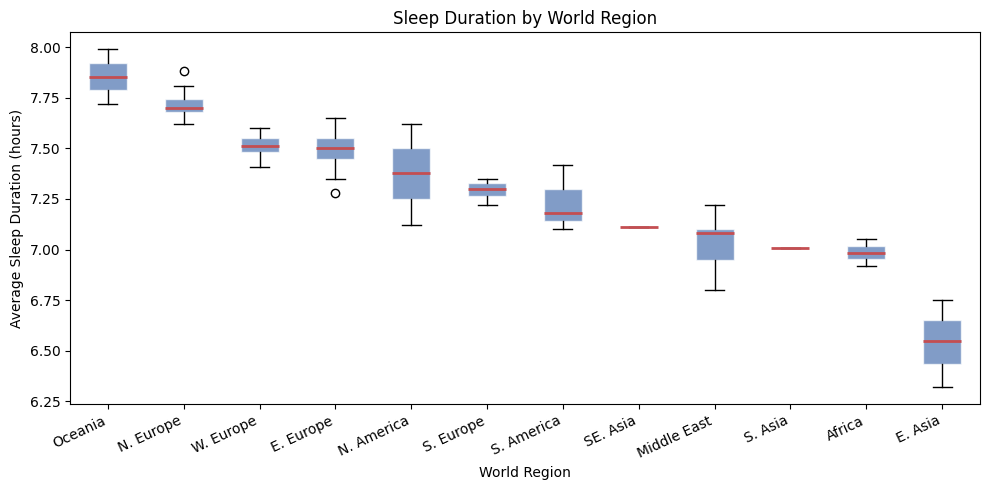


Regional averages:
             Sleep_Duration_hrs  Sleep_Quality  Coffee_kg_per_capita
Region                                                              
Africa                    6.985          0.706                 0.300
E. Asia                   6.540          0.706                 1.967
E. Europe                 7.484          0.749                 2.933
Middle East               7.030          0.711                 0.920
N. America                7.373          0.743                 4.233
N. Europe                 7.722          0.775                 7.225
Oceania                   7.855          0.799                 4.950
S. America                7.233          0.726                 4.200
S. Asia                   7.010          0.712                 0.100
S. Europe                 7.292          0.730                 4.725
SE. Asia                  7.110          0.727                 2.000
W. Europe                 7.509          0.757                 6.067


In [2]:
for col, label in [("Sleep_Duration_hrs", "Sleep Duration (hrs)"),
                   ("Sleep_Quality",       "Sleep Quality Score")]:
    s = df[col]
    print(f"\n{label}")
    print(f"  Mean   = {s.mean():.3f}")
    print(f"  Median = {s.median():.3f}")
    print(f"  SD     = {s.std():.3f}")
    print(f"  Min    = {s.min():.3f}")
    print(f"  Max    = {s.max():.3f}")
    print(f"  IQR    = {s.quantile(0.75) - s.quantile(0.25):.3f}")
    print(f"  Skew   = {stats.skew(s):.3f}")

# histograms of sleep duration and sleep quality
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label, color in zip(axes,
        ["Sleep_Duration_hrs", "Sleep_Quality"],
        ["Average Sleep Duration (hours)", "Sleep Quality Score (0–1)"],
        [BLUE, GREEN]):
    ax.hist(df[col], bins=12, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color=RED, linestyle="--",
               label=f"Mean = {df[col].mean():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of Countries")
    ax.legend()
axes[0].set_title("Distribution of Sleep Duration")
axes[1].set_title("Distribution of Sleep Quality")
plt.tight_layout()
plt.savefig("fig1_sleep_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

# boxplots by region
region_order = (df.groupby("Region")["Sleep_Duration_hrs"]
                  .median().sort_values(ascending=False).index.tolist())
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [df[df["Region"] == r]["Sleep_Duration_hrs"].values for r in region_order],
    labels=region_order,
    patch_artist=True,
    medianprops=dict(color=RED, linewidth=2),
    boxprops=dict(facecolor=BLUE, color="white", alpha=0.7),
)
ax.set_xlabel("World Region")
ax.set_ylabel("Average Sleep Duration (hours)")
ax.set_title("Sleep Duration by World Region")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("fig2_sleep_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRegional averages:")
print(df.groupby("Region")[["Sleep_Duration_hrs", "Sleep_Quality",
                              "Coffee_kg_per_capita"]].mean().round(3))

Question 2


Coffee Consumption (kg/capita/year)
  Mean   = 4.122
  Median = 3.650
  SD     = 2.778
  Min    = 0.100 (India)
  Max    = 12.000 (Finland)
  Skew   = 0.634

Top 5 coffee countries:
       Country  Coffee_kg_per_capita
0      Finland                  12.0
1       Norway                   9.9
2      Iceland                   9.0
3      Denmark                   8.7
4  Netherlands                   8.3

Bottom 5 coffee countries:
         Country  Coffee_kg_per_capita
24         India                   0.1
31       Nigeria                   0.1
30         Egypt                   0.3
23         China                   0.4
29  South Africa                   0.5


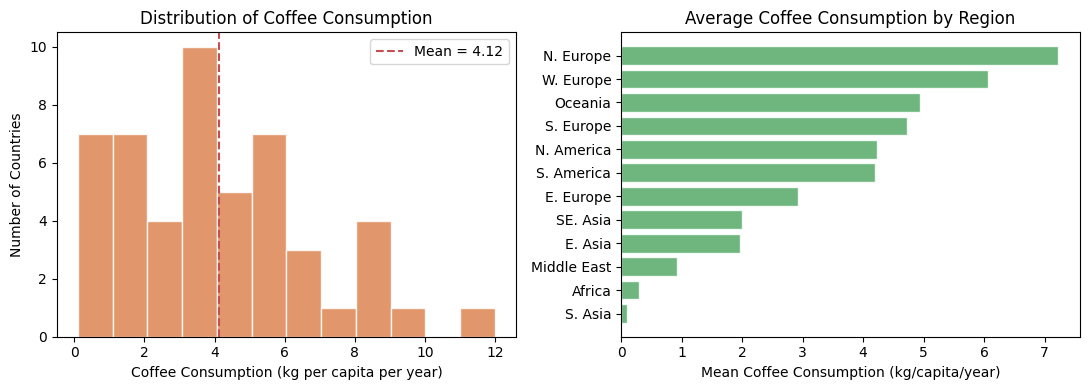

In [3]:
s = df["Coffee_kg_per_capita"]
print(f"\nCoffee Consumption (kg/capita/year)")
print(f"  Mean   = {s.mean():.3f}")
print(f"  Median = {s.median():.3f}")
print(f"  SD     = {s.std():.3f}")
print(f"  Min    = {s.min():.3f} ({df.loc[s.idxmin(), 'Country']})")
print(f"  Max    = {s.max():.3f} ({df.loc[s.idxmax(), 'Country']})")
print(f"  Skew   = {stats.skew(s):.3f}")
print("\nTop 5 coffee countries:")
print(df.nlargest(5,  "Coffee_kg_per_capita")[["Country", "Coffee_kg_per_capita"]])
print("\nBottom 5 coffee countries:")
print(df.nsmallest(5, "Coffee_kg_per_capita")[["Country", "Coffee_kg_per_capita"]])

# coffee histogram + regional bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Coffee_kg_per_capita"], bins=12, color=ORANGE, edgecolor="white", alpha=0.85)
axes[0].axvline(s.mean(), color=RED, linestyle="--", label=f"Mean = {s.mean():.2f}")
axes[0].set_xlabel("Coffee Consumption (kg per capita per year)")
axes[0].set_ylabel("Number of Countries")
axes[0].set_title("Distribution of Coffee Consumption")
axes[0].legend()

region_coffee = df.groupby("Region")["Coffee_kg_per_capita"].mean().sort_values(ascending=False)
axes[1].barh(region_coffee.index, region_coffee.values, color=GREEN, edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Mean Coffee Consumption (kg/capita/year)")
axes[1].set_title("Average Coffee Consumption by Region")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("fig3_coffee_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Question 3 and 4

In [ ]:
r_dur,  p_dur  = stats.pearsonr(df["Coffee_kg_per_capita"], df["Sleep_Duration_hrs"])
r_qual, p_qual = stats.pearsonr(df["Coffee_kg_per_capita"], df["Sleep_Quality"])
print(f"\nCorrelation: Coffee vs. Sleep Duration:  r = {r_dur:.4f}, p = {p_dur:.4f}")
print(f"Correlation: Coffee vs. Sleep Quality:   r = {r_qual:.4f}, p = {p_qual:.4f}")

# scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, ycol, ylabel, title, color in zip(axes,
        ["Sleep_Duration_hrs", "Sleep_Quality"],
        ["Average Sleep Duration (hours)", "Sleep Quality Score (0–1)"],
        ["Coffee vs. Sleep Duration",       "Coffee vs. Sleep Quality"],
        [BLUE, GREEN]):
    ax.scatter(df["Coffee_kg_per_capita"], df[ycol],
               color=color, alpha=0.75, s=50, edgecolors="white", linewidth=0.5)
    m, b, r, *_ = stats.linregress(df["Coffee_kg_per_capita"], df[ycol])
    x_line = np.linspace(df["Coffee_kg_per_capita"].min(),
                         df["Coffee_kg_per_capita"].max(), 100)
    ax.plot(x_line, m * x_line + b, color=RED, linewidth=1.8)
    ax.annotate(f"r = {r:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10)
    ax.set_xlabel("Coffee Consumption (kg per capita per year)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("fig4_scatter_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Question 5


Fitted Normal: mu = 7.366, sigma = 0.338
Shapiro-Wilk: W = 0.9500, p = 0.0343


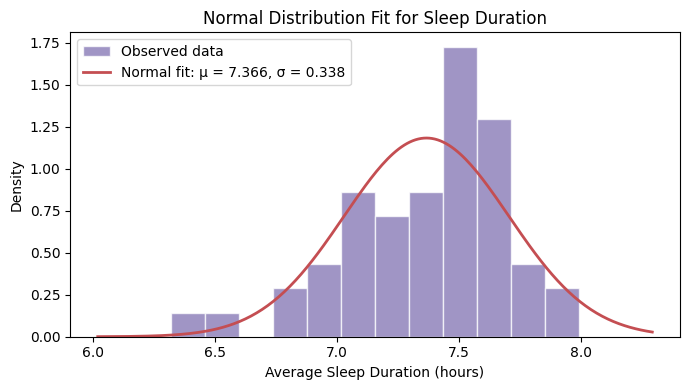


P(Y1 < 7.0) under fitted Normal = 0.1394
Observed proportion below 7.0 hrs = 0.1200
Alpha: =  1409453.4906, Beta = 6.1138


c:\Users\pavlo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_continuous_distns.py:806: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


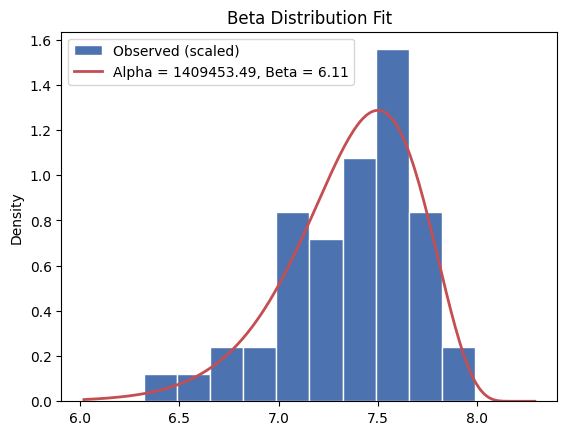

In [ ]:
mu_hat    = df["Sleep_Duration_hrs"].mean()
sigma_hat = df["Sleep_Duration_hrs"].std()
print(f"\nFitted Normal: mu = {mu_hat:.3f}, sigma = {sigma_hat:.3f}")
W, p_sw = stats.shapiro(df["Sleep_Duration_hrs"])
print(f"Shapiro-Wilk: W = {W:.4f}, p = {p_sw:.4f}")

# histogram with Normal density overlay
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["Sleep_Duration_hrs"], bins=12, density=True,
        color=PURPLE, edgecolor="white", alpha=0.75, label="Observed data")
x = np.linspace(df["Sleep_Duration_hrs"].min() - 0.3,
                df["Sleep_Duration_hrs"].max() + 0.3, 200)
ax.plot(x, stats.norm.pdf(x, mu_hat, sigma_hat), color=RED, linewidth=2,
        label=f"Normal fit: μ = {mu_hat:.3f}, σ = {sigma_hat:.3f}")
ax.set_xlabel("Average Sleep Duration (hours)")
ax.set_ylabel("Density")
ax.set_title("Normal Distribution Fit for Sleep Duration")
ax.legend()
plt.tight_layout()
plt.savefig("fig5_normal_fit.png", dpi=150, bbox_inches="tight")
plt.show()

prob = stats.norm.cdf(7.0, mu_hat, sigma_hat)
print(f"\nP(Y1 < 7.0) under fitted Normal = {prob:.4f}")
print(f"Observed proportion below 7.0 hrs = {(df['Sleep_Duration_hrs'] < 7.0).mean():.4f}")


# histogram with Beta density overlay
y = df["Sleep_Duration_hrs"].values
y_min = y.min()
y_max = y.max()
epsilon = 1e-6
y_scaled = (y - 4.0) / (6.0)
y_scaled = np.clip(y_scaled, epsilon, 1- epsilon)


a, b, loc, scale = stats.beta.fit(y_scaled, floc = 0, fscale = 1)
print(f"Alpha: =  {a:.4f}, Beta = {b:.4f}")

x_scaled = np.linspace(000.1, 0.999 , 300)
plt.hist(y_scaled, bins = 10, density= True, color=BLUE, edgecolor = "white", label= "Observed (scaled)")
plt.plot(x_scaled, stats.beta.pdf(x_scaled, a, b, loc=0, scale=1), color = RED, linewidth = 2, label = f"Alpha = {a:.2f}, Beta = {b:.2f}")
plt.xlabel=("Sleep Duration (0 - 1)")
plt.ylabel("Density")
plt.title("Beta Distribution Fit")
plt.legend()
plt.show()